# Session 2 : Training pipeline
- Understand transfer learning
- Implement clean training pipeline
- Parametrize architecture
- Follow PyTorch best practices
- Run

## Imports

In [1]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

## Transforms

In [2]:
# training transform
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# validation and test transform
val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

## Model builder

In [3]:
import torch.nn as nn
import torchvision.models as models


def freeze_all(model):
    for p in model.parameters():
        p.requires_grad = False


def unfreeze_all(model):
    for p in model.parameters():
        p.requires_grad = True


def get_model(cfg):

    if cfg.architecture == "resnet":

        model = models.resnet34(weights="DEFAULT")
        in_feats = model.fc.in_features

        model.fc = nn.Sequential(
            nn.Linear(in_feats, cfg.hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(cfg.hidden_dim, cfg.num_classes)
        )

    elif cfg.architecture == "vgg":

        model = models.vgg16(weights="DEFAULT")
        in_feats = model.classifier[-1].in_features

        model.classifier[-1] = nn.Sequential(
            nn.Linear(in_feats, cfg.hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(cfg.hidden_dim, cfg.num_classes)
        )

    else:
        raise ValueError("Unsupported architecture")

    # training regime
    if cfg.training_mode == "fixed":

        freeze_all(model)

        # classifier must stay trainable
        if cfg.architecture == "resnet":
            for p in model.fc.parameters():
                p.requires_grad = True
        else:
            for p in model.classifier[-1].parameters():
                p.requires_grad = True

    elif cfg.training_mode == "full":

        unfreeze_all(model)

    elif cfg.training_mode == "progressive":

        freeze_all(model)

        if cfg.architecture == "resnet":
            for p in model.fc.parameters():
                p.requires_grad = True
        else:
            for p in model.classifier[-1].parameters():
                p.requires_grad = True

    else:
        raise ValueError("Unknown training mode")

    return model.to(cfg.device)

In [4]:
def unfreeze_top_layers(model, cfg):

    if cfg.architecture == "resnet":
        for p in model.layer4.parameters():
            p.requires_grad = True

    elif cfg.architecture == "vgg":
        for p in model.features[-5:].parameters():
            p.requires_grad = True

## Utils

### Early Stopping

In [5]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0

### Best model

In [6]:
import torch

def save_checkpoint(model, train_mode):
    # Save current model state using mode-specific filename
    path = f"{train_mode}_best_model.pth"
    torch.save(model.state_dict(), path)

### Confusion Matrix

In [7]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

def plot_confusion_matrix(model, loader, class_names, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            outputs = model(imgs)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=class_names)
    disp.plot(cmap="Blues")
    plt.show()

### Plot training curves

In [8]:
import matplotlib.pyplot as plt

def plot_training_curves(train_losses, train_accuracies, val_losses, val_accuracies):

    epochs = range(1, len(train_losses) + 1)

    plt.figure()
    plt.plot(epochs, train_losses, label="Train Loss")
    plt.plot(epochs, val_losses, label="Val Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.title("Loss Curve")
    plt.show()

    plt.figure()
    plt.plot(epochs, train_accuracies, label="Train Accuracy")
    plt.plot(epochs, val_accuracies)
    plt.xlabel("Epochs")
    plt.ylabel("Validation Accuracy")
    plt.title("Accuracy Curve")
    plt.show()

### Train function

In [9]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    
    running_loss = 0
    correct = 0
    
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()

    epoch_loss = running_loss / len(loader)
    epoch_acc = correct / len(loader.dataset)

    return epoch_loss, epoch_acc

### Validation function

In [10]:
def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0
    correct = 0
    
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
    
    acc = correct / len(loader.dataset)
    return running_loss / len(loader), acc

## Training

In [11]:
def train_standard(train_dataset, val_dataset, cfg):

    from torch.utils.data import DataLoader

    train_loader = DataLoader(
        train_dataset,
        batch_size=cfg.batch_size,
        shuffle=True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=cfg.batch_size,
        shuffle=False
    )

    model = get_model(cfg)

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=cfg.lr
    )

    early_stopping = EarlyStopping(patience=cfg.patience_earlystop)
    best_val_loss = float("inf")

    train_losses = []
    train_accuracies = []
    val_losses = []
    val_accuracies = []

    for epoch in range(cfg.epochs):

        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, cfg.device
        )

        val_loss, val_acc = validate(
            model, val_loader, criterion, cfg.device
        )

        print(f"Epoch {epoch+1}")
        print(f"Train Loss: {train_loss:.4f}")
        print(f"Train Acc: {train_acc:.4f}")
        print(f"Val Loss: {val_loss:.4f}")
        print(f"Val Acc: {val_acc:.4f}")
        print("-"*30)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            save_checkpoint(model, cfg.training_mode)

        early_stopping(val_loss)

        if early_stopping.early_stop:
            break

        # progressive fine-tuning trigger
        if cfg.training_mode == "progressive" and epoch == cfg.prg_finetune_epoch:
            unfreeze_top_layers(model, cfg)

        train_losses.append(train_loss)
        train_accuracies.append(train_acc)
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)
    
    
    if cfg.training_mode in ["fixed", "progressive", "full"]:
        model.load_state_dict(torch.load(f"{cfg.training_mode}_best_model.pth"))
    else:
        raise ValueError("Unknown training mode")

    plot_confusion_matrix(
        model,
        val_loader,
        class_names=train_dataset.classes,
        device=cfg.device
    )

    return model, train_losses, train_accuracies, val_losses, val_accuracies

In [ ]:
# Path to dataset and initialize pytorch Imagefolder
from torchvision.datasets import ImageFolder

image_paths = '/path/to/your/data_patch'
data = ImageFolder(root=image_paths, transform=train_transform)


train_dataset = ImageFolder(os.path.join(image_paths, "train"), transform=train_transform)
val_dataset   = ImageFolder(os.path.join(image_paths, "val"), transform=val_transform)
test_dataset  = ImageFolder(os.path.join(image_paths, "test"), transform=val_transform)

print("Classes:", train_dataset.classes)
print("Classes:", val_dataset.class_to_idx)
print("Total images:", len(data))

Classes: ['healthy', 'mildiou']
Classes: {'healthy': 0, 'mildiou': 1}
Total images: 6552


### Configuration

Undersatand transfer-learning regimes :
| mode        | backbone                          | classifier |
| ----------- | --------------------------------- | ---------- |
| fixed       | frozen                            | trainable  |
| progressive | frozen → partially unfrozen later | trainable  |
| full        | trainable                         | trainable  |


In [13]:
class Config:
    architecture = "resnet"          # "resnet" | "vgg"
    training_mode = "fixed"          # "fixed" | "progressive" | "full"

    num_classes = 2
    hidden_dim = 512

    batch_size = 16
    lr = 1e-5
    epochs = 100
    prg_finetune_epoch = 3
    patience_earlystop = 30

    device = "cuda" if torch.cuda.is_available() else "cpu"

cfg = Config()

/home/adjalil/miniforge3/envs/fdeepl/lib/python3.10/site-packages/torch/cuda/__init__.py:129: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at ../c10/cuda/CUDAFunctions.cpp:108.)
  return torch._C._cuda_getDeviceCount() > 0


### Run training

Epoch 1
Train Loss: 0.5609
Train Acc: 0.7353
Val Loss: 0.4437
Val Acc: 0.8444
------------------------------
Epoch 2
Train Loss: 0.4896
Train Acc: 0.7657
Val Loss: 0.4066
Val Acc: 0.8496
------------------------------
Epoch 3
Train Loss: 0.4458
Train Acc: 0.8053
Val Loss: 0.3880
Val Acc: 0.8513
------------------------------
Epoch 4
Train Loss: 0.4111
Train Acc: 0.8267
Val Loss: 0.3667
Val Acc: 0.8573
------------------------------
Epoch 5
Train Loss: 0.3845
Train Acc: 0.8390
Val Loss: 0.3509
Val Acc: 0.8615
------------------------------
Epoch 6
Train Loss: 0.3686
Train Acc: 0.8473
Val Loss: 0.3459
Val Acc: 0.8650
------------------------------
Epoch 7
Train Loss: 0.3510
Train Acc: 0.8528
Val Loss: 0.3375
Val Acc: 0.8658
------------------------------
Epoch 8
Train Loss: 0.3403
Train Acc: 0.8606
Val Loss: 0.3328
Val Acc: 0.8675
------------------------------
Epoch 9
Train Loss: 0.3384
Train Acc: 0.8594
Val Loss: 0.3341
Val Acc: 0.8632
------------------------------
Epoch 10
Train Loss

/tmp/ipykernel_51265/51160226.py:71: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f"{cfg.training_mode}_best_model.pth"))


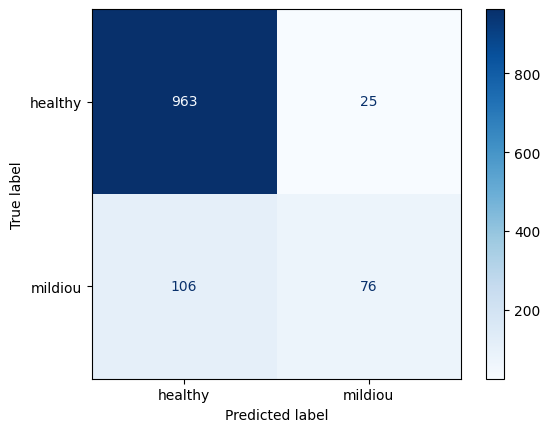

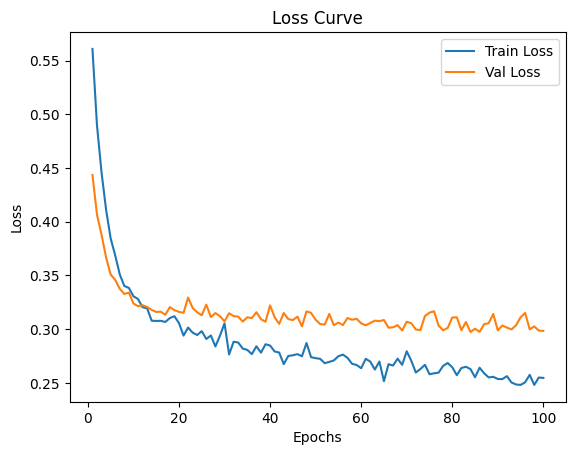

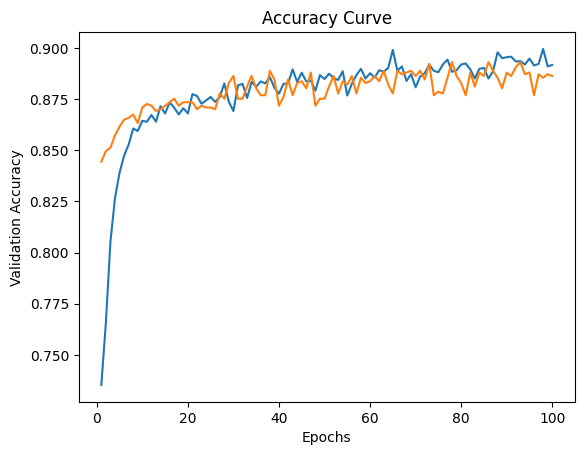

In [14]:
# Training
model, train_losses, train_acc, val_losses, val_acc = train_standard(
    train_dataset,
    val_dataset,
    cfg
)

# Plot graphics
plot_training_curves(train_losses, train_acc, val_losses, val_acc)